# Hier-2 Forecast — Vermont (VT) Climate Transfer

Transfers the Hier-2 hierarchical SAC architecture to the
`annex96_ce1_vt_neighborhood` (Vermont, heating-dominated) dataset.
Addresses **Research Question 4**: climate transferability.

**Run order:**
1. Setup (this cell + cell 2)
2. Train lower-level per-building SAC agents on VT data (~9 h)
3. Evaluate and save lower-level agents
4. Train upper-level Hier-2 coordinator on VT data (~4 h)
5. Evaluate Hier-2 VT and report KPIs

**Key VT vs TX differences:**
| | TX | VT |
|---|---|---|
| Sim window | 3624–4343 (720 steps) | 0–743 (744 steps) |
| Target mean | ~19.5 kWh/h | ~100 kWh/h |
| Active HVAC | cooling device | heating device |
| Deactivated | cooling_device | heating_device |
| Obs norm scale | 30 | 100 |
| Slope scale | 10 | 50 |

In [ ]:
import sys, os, json, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
import wandb
import plotly.graph_objects as go
warnings.filterwarnings('ignore')
os.environ['WANDB_SILENT'] = 'true'
os.environ['WANDB_API_KEY'] = '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'

HERE = Path.cwd()
REPO_DIR = next(p for p in [HERE] + list(HERE.parents) if (p / 'citylearn').is_dir())
sys.path.insert(0, str(REPO_DIR))
sys.path.insert(0, str(REPO_DIR / 'SERVER'))
sys.path.insert(0, str(REPO_DIR / 'harish_work'))

from citylearn.citylearn import CityLearnEnv
from citylearn.reward_function import RewardFunction
from citylearn.rl import PolicyNetwork, SoftQNetwork, ReplayBuffer
from feature_engineer import FeatureEngineer
from KPIs import compute_kpis
import gymnasium as gym

# ── Paths ───────────────────────────────────────────────────────────────
DATASET_DIR = REPO_DIR / 'data' / 'datasets' / 'annex96_ce1_vt_neighborhood'
SCHEMA_PATH = DATASET_DIR / 'schema.json'
MODELS_DIR  = Path(r'C:/Users/20213697/citylearn_models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

LOWER_MODEL_NAME = 'Decentralized-SAC-Battery-VT'
UPPER_MODEL_NAME = 'Hierarchical-Hier2-Forecast-VT'

# ── W&B ─────────────────────────────────────────────────────────────────
WANDB_ENTITY  = 'CityLearn-TeamB'
WANDB_PROJECT = 'CityLearn'

# ── Simulation constants ─────────────────────────────────────────────────
VT_SIM_START   = 0
VT_SIM_END     = 743      # 744 steps = 31 days
N_EPISODES     = 100
ACT_DIM        = 1
TRACKING_SCALE = 100.0    # VT target ~100 kWh/h (TX used 1000 for ~19.5 kWh/h)
NORM_SCALE     = 100.0    # upper-level obs normalisation
SLOPE_SCALE    = 50.0     # target slope normalisation

district_target = pd.read_csv(DATASET_DIR / 'district_target.csv')[
    'district_load_target'].values[VT_SIM_START:VT_SIM_END + 1]
target_list = district_target.tolist()

print(f'VT target: {len(district_target)} steps, '
      f'mean={district_target.mean():.1f}, '
      f'min={district_target.min():.1f}, '
      f'max={district_target.max():.1f} kWh/h')
print(f'Lower model -> {MODELS_DIR / LOWER_MODEL_NAME}')
print(f'Upper model -> {MODELS_DIR / UPPER_MODEL_NAME}')

In [ ]:
# ── Reward function ──────────────────────────────────────────────────────
class TrackingReward(RewardFunction):
    def __init__(self, env_metadata, district_target, scale=100.0, **kwargs):
        super().__init__(env_metadata)
        self._target = list(district_target)
        self._scale  = float(scale)
        self._step   = 0

    def calculate(self, observations):
        tgt  = self._target[min(self._step, len(self._target) - 1)]
        load = sum(o.get('net_electricity_consumption', 0.0) for o in observations)
        r    = -((load - tgt) ** 2) * self._scale
        self._step += 1
        return [r / len(observations)] * len(observations)

    def reset(self):
        self._step = 0


# ── SAC components ───────────────────────────────────────────────────────
class UpperSAC:
    def __init__(self, obs_dim, act_dim=1, hidden=None, lr=3e-4,
                 buffer_capacity=72000, batch_size=128,
                 gamma=0.99, tau=0.005, alpha=0.2, standardize_after=512):
        hidden = hidden or [64, 64]
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        action_space = gym.spaces.Box(
            low=np.full(act_dim, -1.0), high=np.full(act_dim, 1.0), dtype=np.float32)
        self.q1  = SoftQNetwork(obs_dim, act_dim, hidden).to(self.device)
        self.q2  = SoftQNetwork(obs_dim, act_dim, hidden).to(self.device)
        self.tq1 = SoftQNetwork(obs_dim, act_dim, hidden).to(self.device)
        self.tq2 = SoftQNetwork(obs_dim, act_dim, hidden).to(self.device)
        self.tq1.load_state_dict(self.q1.state_dict())
        self.tq2.load_state_dict(self.q2.state_dict())
        self.policy = PolicyNetwork(obs_dim, act_dim, action_space, 1.0, hidden).to(self.device)
        self.q1_opt = optim.Adam(self.q1.parameters(), lr=lr)
        self.q2_opt = optim.Adam(self.q2.parameters(), lr=lr)
        self.p_opt  = optim.Adam(self.policy.parameters(), lr=lr)
        self.buf  = ReplayBuffer(buffer_capacity)
        self.crit = nn.SmoothL1Loss()
        self.batch_size = batch_size; self.gamma = gamma
        self.tau = tau; self.alpha = alpha
        self.standardize_after = standardize_after
        self.norm_mean = self.norm_std = None; self._normalized = False

    def _norm(self, obs):
        if self.norm_mean is None: return obs
        return (obs - self.norm_mean) / (self.norm_std + 1e-5)

    def act(self, obs, deterministic=False):
        with torch.no_grad():
            o = torch.FloatTensor(self._norm(obs)).unsqueeze(0).to(self.device)
            result = self.policy.sample(o)
            a = result[2] if deterministic else result[0]
        return a.detach().cpu().numpy()[0]

    def update(self, obs, action, reward, next_obs, done):
        action = np.atleast_1d(np.array(action, dtype=np.float32))
        push_obs  = self._norm(obs)      if self._normalized else obs
        push_next = self._norm(next_obs) if self._normalized else next_obs
        self.buf.push(push_obs, action, reward, push_next, done)
        if len(self.buf.buffer) < self.batch_size: return
        if not self._normalized and len(self.buf.buffer) >= self.standardize_after:
            X = np.array([j[0] for j in self.buf.buffer], dtype=float)
            self.norm_mean = np.nanmean(X, axis=0)
            self.norm_std  = np.nanstd(X, axis=0) + 1e-5
            self.buf.buffer = [(self._norm(o), a, r, self._norm(n), d)
                               for o, a, r, n, d in self.buf.buffer]
            self._normalized = True
        o, a, r, n, d = self.buf.sample(self.batch_size)
        F = torch.FloatTensor
        o=F(o).to(self.device); n=F(n).to(self.device); a=F(a).to(self.device)
        r=F(r).unsqueeze(1).to(self.device); d=F(d).unsqueeze(1).to(self.device)
        with torch.no_grad():
            na, nlp, _ = self.policy.sample(n)
            qt = torch.min(self.tq1(n,na), self.tq2(n,na)) - self.alpha*nlp
            qt = r + (1 - d)*self.gamma*qt
        for q, opt in [(self.q1, self.q1_opt), (self.q2, self.q2_opt)]:
            loss = self.crit(q(o,a), qt); opt.zero_grad(); loss.backward(); opt.step()
        na2, lp2, _ = self.policy.sample(o)
        pl = (self.alpha*lp2 - torch.min(self.q1(o,na2), self.q2(o,na2))).mean()
        self.p_opt.zero_grad(); pl.backward(); self.p_opt.step()
        for tq, q in [(self.tq1,self.q1),(self.tq2,self.q2)]:
            for tp, p in zip(tq.parameters(), q.parameters()):
                tp.data.copy_(tp.data*(1-self.tau) + p.data*self.tau)


class DecentralizedFESAC:
    FE_OBS_DIM = 9

    def __init__(self, env, act_dim=1):
        obs_names      = [n for n in env.observation_names if isinstance(n, list)]
        self.engineers = [FeatureEngineer(names) for names in obs_names]
        self.agents    = [UpperSAC(obs_dim=self.FE_OBS_DIM, act_dim=act_dim)
                          for _ in obs_names]

    def _transform(self, raw_obs_list):
        return [np.array(eng.process_for_ml(obs), dtype=np.float32)
                for eng, obs in zip(self.engineers, raw_obs_list)]

    def _reset_engineers(self, initial_obs_list=None):
        for i, eng in enumerate(self.engineers):
            eng.temp_history.clear()
            if initial_obs_list is not None and eng.outdoor_temp_idx is not None:
                init_t = float(initial_obs_list[i][eng.outdoor_temp_idx])
                eng.temp_history.extend([init_t, init_t])

    def _clip_actions(self, actions):
        clipped = []
        for a in actions:
            a = list(np.atleast_1d(a))
            a[0] = float(np.clip(a[0], -1.0, 1.0))
            if len(a) > 1:
                a[1] = float(np.clip(a[1], 0.0, 1.0))
            clipped.append(a)
        return clipped

    def train_on(self, env, n_episodes=N_EPISODES, log_every=10):
        t0 = time.time(); ep_rewards = []
        for ep in range(n_episodes):
            raw_obs, _ = env.reset()
            self._reset_engineers(raw_obs)
            feat = self._transform(raw_obs)
            ep_r = 0.0
            while not env.terminated:
                actions = [ag.act(f, deterministic=False)
                           for ag, f in zip(self.agents, feat)]
                actions = self._clip_actions(actions)
                raw_next, rewards, terminated, truncated, _ = env.step(actions)
                feat_next = self._transform(raw_next)
                for ag, f, a, r, fn in zip(self.agents, feat, actions, rewards, feat_next):
                    ag.update(f, a, float(r), fn, terminated)
                feat = feat_next
                ep_r += float(np.sum(rewards))
            ep_rewards.append(ep_r)
            if (ep+1) % log_every == 0 or ep == 0:
                print(f'  ep {ep+1:3d}/{n_episodes}  reward={ep_r:14.1f}  '
                      f'elapsed={(time.time()-t0)/60:.1f} min')
        print(f'Training done in {(time.time()-t0)/60:.1f} min')
        return ep_rewards

    def predict(self, raw_obs_list, deterministic=True):
        feat = self._transform(raw_obs_list)
        return [ag.act(f, deterministic=deterministic)
                for ag, f in zip(self.agents, feat)]

    def evaluate(self, eval_env):
        raw_obs, _ = eval_env.reset()
        self._reset_engineers(raw_obs)
        feat = self._transform(raw_obs)
        while not eval_env.terminated:
            actions = self._clip_actions(
                [ag.act(f, deterministic=True) for ag, f in zip(self.agents, feat)])
            raw_next, _, _, _, _ = eval_env.step(actions)
            feat = self._transform(raw_next)

    def save(self, directory):
        directory = Path(directory); directory.mkdir(parents=True, exist_ok=True)
        for i, ag in enumerate(self.agents):
            torch.save(ag.policy.state_dict(), directory / f'policy_{i}.pt')
            torch.save(ag.q1.state_dict(),     directory / f'q1_{i}.pt')
            torch.save(ag.q2.state_dict(),     directory / f'q2_{i}.pt')
            np.save(directory / f'norm_mean_{i}.npy',
                    ag.norm_mean if ag.norm_mean is not None else np.array([]))
            np.save(directory / f'norm_std_{i}.npy',
                    ag.norm_std  if ag.norm_std  is not None else np.array([]))
        print(f'Saved {len(self.agents)} agents to {directory}')

    @classmethod
    def load(cls, env, directory, act_dim=1):
        obj = cls(env, act_dim=act_dim)
        directory = Path(directory)
        for i, ag in enumerate(obj.agents):
            ag.policy.load_state_dict(torch.load(directory / f'policy_{i}.pt',
                                                  map_location=ag.device))
            ag.q1.load_state_dict(torch.load(directory / f'q1_{i}.pt',
                                             map_location=ag.device))
            ag.q2.load_state_dict(torch.load(directory / f'q2_{i}.pt',
                                             map_location=ag.device))
            nm = np.load(directory / f'norm_mean_{i}.npy')
            ns = np.load(directory / f'norm_std_{i}.npy')
            ag.norm_mean = nm if nm.size else None
            ag.norm_std  = ns if ns.size else None
            ag._normalized = ag.norm_mean is not None
        print(f'Loaded {len(obj.agents)} agents from {directory.name}')
        return obj


# ── VT Hierarchical environment ──────────────────────────────────────────
class HierarchicalEnvVT:
    OBS_DIM        = 9
    DELTA_SCALE    = 0.35
    EMA_ALPHA      = 0.4
    ACTION_PENALTY = 0.05
    TRACK_PENALTY  = 0.001
    NORM_SCALE     = 100.0
    SLOPE_SCALE    = 50.0

    def __init__(self, citylearn_env, lower_agent, target):
        self._env        = citylearn_env
        self._lower      = lower_agent
        self._target     = target
        self._step       = 0
        self._prev_load  = float(target[0])
        self._smooth_act = 0.0
        self._lower_obs  = None
        self.terminated  = False

    def _mean_soc(self):
        socs = [float(b.electrical_storage.soc[-1])
                if len(b.electrical_storage.soc) > 0 else 0.5
                for b in self._env.buildings]
        return float(np.mean(socs))

    def _upper_obs(self):
        h      = self._step % 24
        t      = min(self._step, len(self._target) - 1)
        tgt    = self._target[t]
        tgt_6  = self._target[min(t + 6,  len(self._target) - 1)]
        tgt_12 = self._target[min(t + 12, len(self._target) - 1)]
        N, SL  = self.NORM_SCALE, self.SLOPE_SCALE
        return np.array([
            np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24),
            self._prev_load / N, tgt / N,
            (self._prev_load - tgt) / N,
            self._mean_soc(),
            tgt_6 / N, tgt_12 / N,
            (tgt_6 - tgt) / SL,
        ], dtype=np.float32)

    def reset(self):
        self._lower_obs, _ = self._env.reset()
        self._lower._reset_engineers(self._lower_obs)
        self._step       = 0
        self._prev_load  = float(self._target[0])
        self._smooth_act = 0.0
        self.terminated  = False
        return self._upper_obs(), {}

    def step(self, upper_action):
        raw     = float(np.clip(upper_action[0], -1.0, 1.0)) * self.DELTA_SCALE
        delta_a = self.EMA_ALPHA * raw + (1 - self.EMA_ALPHA) * self._smooth_act
        self._smooth_act = delta_a
        lower_actions = self._lower.predict(self._lower_obs, deterministic=True)
        corrected = []
        for a in lower_actions:
            al = list(np.atleast_1d(a))
            al[0] = float(np.clip(al[0] + delta_a, -1.0, 1.0))
            corrected.append(al)
        try:
            self._lower_obs, _, term, _, _ = self._env.step(corrected)
        except AssertionError:
            self._lower_obs, _, term, _, _ = self._env.step(
                [list(np.atleast_1d(a)) for a in lower_actions])
        self._prev_load = float(
            sum(b.net_electricity_consumption[-1] for b in self._env.buildings))
        tgt    = self._target[min(self._step, len(self._target) - 1)]
        reward = (-self.TRACK_PENALTY * (self._prev_load - tgt) ** 2
                  - self.ACTION_PENALTY * delta_a ** 2)
        self._step    += 1
        self.terminated = term
        obs = self._upper_obs() if not term else np.zeros(self.OBS_DIM, dtype=np.float32)
        return obs, reward, term, False, {}

    @property
    def net_electricity_consumption(self):
        return self._env.net_electricity_consumption


# ── Environment factory ──────────────────────────────────────────────────
def make_env():
    with open(SCHEMA_PATH) as f:
        schema = json.load(f)
    schema = copy.deepcopy(schema)
    for bid in schema['buildings']:
        schema['buildings'][bid]['inactive_actions'] = ['heating_device', 'dhw_storage']
    env = CityLearnEnv(
        schema=schema,
        root_directory=str(DATASET_DIR),
        central_agent=False,
        reward_function=TrackingReward,
        reward_function_kwargs={'district_target': target_list,
                                'scale': TRACKING_SCALE},
    )
    env.reset()
    return env


# ── W&B logging ──────────────────────────────────────────────────────────
def log_to_wandb(controller_name, district_load, kpis=None, building_temps=None):
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=controller_name, reinit=True,
                     settings=wandb.Settings(console='off'))
    if kpis is not None:
        wandb.log({
            'NMBE [%]':                      float(kpis['NMBE [%]']),
            'CV-RMSE [%]':                   float(kpis['CV-RMSE [%]']),
            'Temp Comfort violation [%]':     float(kpis['Temp Comfort violation [%]']),
        })
    wandb.define_metric('hour')
    wandb.define_metric('district_load', step_metric='hour')
    for t, v in enumerate(district_load):
        wandb.log({'hour': t, 'district_load': float(v)})
    if building_temps is not None:
        T   = building_temps.shape[0]
        fig = go.Figure()
        fig.add_hrect(y0=22, y1=26, fillcolor='green', opacity=0.12, line_width=0,
                      annotation_text='Comfort [22-26°C]',
                      annotation_position='top right')
        fig.add_hline(y=22, line_dash='dash', line_color='red', line_width=1)
        fig.add_hline(y=26, line_dash='dash', line_color='red', line_width=1)
        for b in range(building_temps.shape[1]):
            fig.add_trace(go.Scatter(
                x=list(range(T)), y=building_temps[:, b], mode='lines',
                line=dict(color='rgba(70,130,180,0.2)', width=1), showlegend=False))
        fig.add_trace(go.Scatter(
            x=list(range(T)), y=building_temps.mean(axis=1), mode='lines',
            line=dict(color='steelblue', width=3), name='Mean temp'))
        fig.update_layout(title=f'{controller_name} — Indoor Temperature',
                          xaxis_title='Hour', yaxis_title='Temp [°C]')
        wandb.log({'temperature_plot': wandb.Plotly(fig)})
    wandb.finish()
    print(f'Uploaded to W&B: {controller_name}')


# Verify environment loads correctly
_test = make_env()
print(f'Env ready. Action space[0]: {_test.action_space[0]}  (battery only)')
print(f'Buildings: {len(_test.buildings)}')
del _test
print('All classes defined.')

In [16]:
# ── W&B logging ──────────────────────────────────────────────────────────
def log_to_wandb(controller_name, district_load, kpis=None, building_temps=None):
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=controller_name, reinit=True,
                     settings=wandb.Settings(console='off'))
    if kpis is not None:
        wandb.log({
            'NMBE [%]':                   float(kpis['NMBE [%]']),
            'CV-RMSE [%]':                float(kpis['CV-RMSE [%]']),
            'Temp Comfort violation [%]': float(kpis['Temp Comfort violation [%]']),
        })
    wandb.define_metric('hour')
    wandb.define_metric('district_load', step_metric='hour')
    for t, v in enumerate(district_load):
        wandb.log({'hour': t, 'district_load': float(v)})
    if building_temps is not None:
        T   = building_temps.shape[0]
        fig = go.Figure()
        fig.add_hrect(y0=22, y1=26, fillcolor='green', opacity=0.12, line_width=0,
                      annotation_text='Comfort [22-26 C]',
                      annotation_position='top right')
        fig.add_hline(y=22, line_dash='dash', line_color='red', line_width=1)
        fig.add_hline(y=26, line_dash='dash', line_color='red', line_width=1)
        for b in range(building_temps.shape[1]):
            fig.add_trace(go.Scatter(
                x=list(range(T)), y=building_temps[:, b], mode='lines',
                line=dict(color='rgba(70,130,180,0.2)', width=1), showlegend=False))
        fig.add_trace(go.Scatter(
            x=list(range(T)), y=building_temps.mean(axis=1), mode='lines',
            line=dict(color='steelblue', width=3), name='Mean temp'))
        fig.update_layout(title=controller_name + ' - Indoor Temperature',
                          xaxis_title='Hour', yaxis_title='Temp [C]')
        wandb.log({'temperature_plot': wandb.Plotly(fig)})
    wandb.finish()
    print('Uploaded to W&B: ' + controller_name)

print('log_to_wandb defined.')

log_to_wandb defined.


## Stage 1 — Train Lower-Level SAC Agents on VT Data

25 independent per-building SAC agents trained from scratch on the VT dataset.
Expected wall-clock time: ~9 hours on CPU.

In [3]:
env_lower  = make_env()
lower_agent = DecentralizedFESAC(env_lower, act_dim=ACT_DIM)
ep_rewards_lower = lower_agent.train_on(env_lower, n_episodes=N_EPISODES)

  ep   1/100  reward=  -239055218.8  elapsed=4.0 min
  ep  10/100  reward=  -235903551.3  elapsed=54.7 min
  ep  20/100  reward=  -241802494.1  elapsed=109.8 min
  ep  30/100  reward=  -237792438.1  elapsed=165.6 min
  ep  40/100  reward=  -237841185.5  elapsed=222.4 min
  ep  50/100  reward=  -234413515.1  elapsed=279.3 min
  ep  60/100  reward=  -233939029.3  elapsed=335.5 min
  ep  70/100  reward=  -233852861.5  elapsed=391.7 min
  ep  80/100  reward=  -234346646.9  elapsed=446.8 min
  ep  90/100  reward=  -233766263.6  elapsed=501.8 min
  ep 100/100  reward=  -228191490.7  elapsed=557.3 min
Training done in 557.3 min


In [4]:
# Save immediately after training
save_dir_lower = MODELS_DIR / LOWER_MODEL_NAME
lower_agent.save(save_dir_lower)
np.save(save_dir_lower / 'episode_rewards.npy', np.array(ep_rewards_lower))
print(f'Lower-level agents saved to {save_dir_lower}')

Saved 25 agents to C:\Users\20213697\citylearn_models\Decentralized-SAC-Battery-VT
Lower-level agents saved to C:\Users\20213697\citylearn_models\Decentralized-SAC-Battery-VT


In [21]:
# Evaluate lower-level agents
eval_env_lower = make_env()
lower_agent.evaluate(eval_env_lower)

district_load_lower = np.array(eval_env_lower.net_electricity_consumption)
building_temps_lower = np.array([
    b.energy_simulation.indoor_dry_bulb_temperature[:len(district_target)]
    for b in eval_env_lower.buildings
]).T

kpis_lower = compute_kpis(district_target, district_load_lower, building_temps_lower)
print('Lower-level SAC (VT) KPIs:')
for k, v in kpis_lower.items():
    print(f'  {k}: {v:.3f}')

log_to_wandb(LOWER_MODEL_NAME, district_load_lower, kpis_lower, building_temps_lower)

Lower-level SAC (VT) KPIs:
  NMBE [%]: 20.618
  CV-RMSE [%]: 54.254
  Temp Comfort violation [%]: 89.840
Uploaded to W&B: Decentralized-SAC-Battery-VT


## Stage 2 — Train Upper-Level Hier-2 Coordinator on VT Data

Single district-level SAC coordinator on top of the frozen VT lower-level agents.
Expected wall-clock time: ~4 hours on CPU.

In [6]:
# Reload frozen lower-level agents (safe to re-run after kernel restart)
assert (MODELS_DIR / LOWER_MODEL_NAME).exists(), (
    f'Lower model not found: {MODELS_DIR / LOWER_MODEL_NAME}\n'
    'Run Stage 1 cells first.')

dec_env_upper   = make_env()
frozen_lower    = DecentralizedFESAC.load(dec_env_upper, MODELS_DIR / LOWER_MODEL_NAME)
hier_env        = HierarchicalEnvVT(dec_env_upper, frozen_lower, district_target)
upper_sac       = UpperSAC(HierarchicalEnvVT.OBS_DIM, act_dim=ACT_DIM)

print(f'Upper-level obs dim: {HierarchicalEnvVT.OBS_DIM}')
print(f'NORM_SCALE={HierarchicalEnvVT.NORM_SCALE},  '
      f'SLOPE_SCALE={HierarchicalEnvVT.SLOPE_SCALE}')

Loaded 25 agents from Decentralized-SAC-Battery-VT
Upper-level obs dim: 9
NORM_SCALE=100.0,  SLOPE_SCALE=50.0


In [7]:
# Train upper-level coordinator
t0 = time.time()
ep_rewards_upper = []
print(f'Training Hier-2 upper SAC on VT ({N_EPISODES} episodes)...')
for ep in range(N_EPISODES):
    obs, _ = hier_env.reset()
    ep_r   = 0.0
    while not hier_env.terminated:
        action            = upper_sac.act(obs, deterministic=False)
        next_obs, reward, done, _, _ = hier_env.step(action)
        upper_sac.update(obs, action, reward, next_obs, done)
        obs  = next_obs; ep_r += reward
    ep_rewards_upper.append(ep_r)
    if (ep + 1) % 10 == 0 or ep == 0:
        print(f'  ep {ep+1:3d}/{N_EPISODES}  reward={ep_r:9.1f}  '
              f'elapsed={(time.time()-t0)/60:.1f} min')
print(f'Done in {(time.time()-t0)/60:.1f} min')

Training Hier-2 upper SAC on VT (100 episodes)...
  ep   1/100  reward=  -2113.7  elapsed=1.5 min
  ep  10/100  reward=  -1582.7  elapsed=15.8 min
  ep  20/100  reward=  -1677.7  elapsed=31.9 min
  ep  30/100  reward=  -1665.6  elapsed=47.9 min
  ep  40/100  reward=  -1635.9  elapsed=63.9 min
  ep  50/100  reward=  -1662.7  elapsed=79.7 min
  ep  60/100  reward=  -1682.9  elapsed=94.7 min
  ep  70/100  reward=  -1651.2  elapsed=109.7 min
  ep  80/100  reward=  -1705.3  elapsed=124.6 min
  ep  90/100  reward=  -1712.3  elapsed=140.8 min
  ep 100/100  reward=  -1757.3  elapsed=156.8 min
Done in 156.8 min


In [8]:
# Save upper-level SAC immediately
save_dir_upper = MODELS_DIR / UPPER_MODEL_NAME
save_dir_upper.mkdir(parents=True, exist_ok=True)
torch.save(upper_sac.policy.state_dict(), save_dir_upper / 'upper_policy.pt')
np.save(save_dir_upper / 'upper_norm_mean.npy',
        upper_sac.norm_mean if upper_sac.norm_mean is not None else np.array([]))
np.save(save_dir_upper / 'upper_norm_std.npy',
        upper_sac.norm_std  if upper_sac.norm_std  is not None else np.array([]))
np.save(save_dir_upper / 'episode_rewards.npy', np.array(ep_rewards_upper))
print(f'Upper SAC saved to {save_dir_upper}')

Upper SAC saved to C:\Users\20213697\citylearn_models\Hierarchical-Hier2-Forecast-VT


## Stage 3 — Evaluate Hier-2 VT and Report KPIs

In [22]:
# Auto-reload upper SAC from disk if kernel was restarted after training
if 'upper_sac' not in vars() or not hasattr(upper_sac, 'policy'):
    assert (MODELS_DIR / UPPER_MODEL_NAME).exists(), (
        f'Upper model not found: {MODELS_DIR / UPPER_MODEL_NAME}\n'
        'Run Stage 2 cells first.')
    upper_sac = UpperSAC(HierarchicalEnvVT.OBS_DIM, act_dim=ACT_DIM)
    sd = MODELS_DIR / UPPER_MODEL_NAME
    upper_sac.policy.load_state_dict(
        torch.load(sd / 'upper_policy.pt', map_location=upper_sac.device))
    nm = np.load(sd / 'upper_norm_mean.npy')
    ns = np.load(sd / 'upper_norm_std.npy')
    upper_sac.norm_mean = nm if nm.size else None
    upper_sac.norm_std  = ns if ns.size else None
    upper_sac._normalized = upper_sac.norm_mean is not None
    print('Reloaded upper SAC from disk.')

# Deterministic evaluation
eval_dec_env  = make_env()
eval_lower    = DecentralizedFESAC.load(eval_dec_env, MODELS_DIR / LOWER_MODEL_NAME)
eval_hier_env = HierarchicalEnvVT(eval_dec_env, eval_lower, district_target)

obs, _ = eval_hier_env.reset()
while not eval_hier_env.terminated:
    action = upper_sac.act(obs, deterministic=True)
    obs, _, _, _, _ = eval_hier_env.step(action)

district_load_hier = np.array(eval_hier_env.net_electricity_consumption)
building_temps_hier = np.array([
    b.energy_simulation.indoor_dry_bulb_temperature[:len(district_target)]
    for b in eval_dec_env.buildings
]).T

kpis_hier = compute_kpis(district_target, district_load_hier, building_temps_hier)
print('Hier-2 VT KPIs:')
for k, v in kpis_hier.items():
    print(f'  {k}: {v:.3f}')

log_to_wandb(UPPER_MODEL_NAME, district_load_hier, kpis_hier, building_temps_hier)

Loaded 25 agents from Decentralized-SAC-Battery-VT
Hier-2 VT KPIs:
  NMBE [%]: 20.698
  CV-RMSE [%]: 48.142
  Temp Comfort violation [%]: 89.840
Uploaded to W&B: Hierarchical-Hier2-Forecast-VT


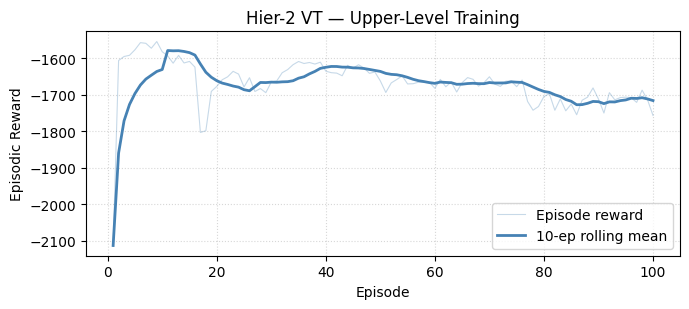

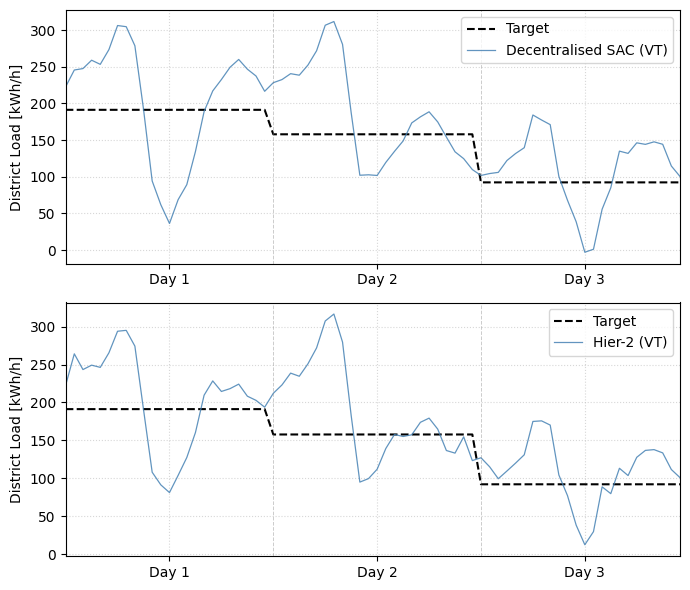


── KPI Summary ─────────────────────────────────────────────
Controller                           NMBE [%]  CV-RMSE [%]  Temp Viol [%]
------------------------------------------------------------------------
Dec SAC (VT)                            20.62        54.25          89.84
Hier-2 (VT)                             20.70        48.14          89.84


In [23]:
# ── Training reward curve ────────────────────────────────────────────────
ep_rw = np.load(MODELS_DIR / UPPER_MODEL_NAME / 'episode_rewards.npy')
rolling = pd.Series(ep_rw).rolling(10, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.arange(1, len(ep_rw)+1), ep_rw, color='steelblue',
        alpha=0.3, linewidth=0.8, label='Episode reward')
ax.plot(np.arange(1, len(ep_rw)+1), rolling, color='steelblue',
        linewidth=2.0, label='10-ep rolling mean')
ax.set_xlabel('Episode'); ax.set_ylabel('Episodic Reward')
ax.set_title('Hier-2 VT — Upper-Level Training')
ax.legend(); ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.show()

# ── District load profile (first 3 days) ────────────────────────────────
N_PLOT = 72
hours  = np.arange(N_PLOT)

fig, axes = plt.subplots(2, 1, figsize=(7, 6))
for ax, load, label in zip(axes,
                            [district_load_lower, district_load_hier],
                            ['Decentralised SAC (VT)', 'Hier-2 (VT)']):
    ax.plot(hours, district_target[:N_PLOT], 'k--', linewidth=1.5, label='Target')
    ax.plot(hours, load[:N_PLOT], color='steelblue', linewidth=0.9,
            alpha=0.85, label=label)
    ax.set_ylabel('District Load [kWh/h]')
    ax.legend(); ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xticks([12, 36, 60])
    ax.set_xticklabels(['Day 1', 'Day 2', 'Day 3'])
    ax.set_xlim(0, N_PLOT - 1)
    for b in [24, 48]:
        ax.axvline(b, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)
plt.tight_layout(); plt.show()

# ── Summary table ────────────────────────────────────────────────────────
print('\n── KPI Summary ─────────────────────────────────────────────')
print(f'{"Controller":<35} {"NMBE [%]":>9} {"CV-RMSE [%]":>12} {"Temp Viol [%]":>14}')
print('-' * 72)
for name, kpis in [(f'Dec SAC (VT)', kpis_lower), (f'Hier-2 (VT)', kpis_hier)]:
    print(f'{name:<35} '
          f'{kpis["NMBE [%]"]:>9.2f} '
          f'{kpis["CV-RMSE [%]"]:>12.2f} '
          f'{kpis["Temp Comfort violation [%]"]:>14.2f}')